# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [2]:
import sys

sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
from fastfeedback import *


caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]
Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG = "rec/mc/mc.nu/mc.nu.pdg"
data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

df: pl.DataFrame = pl.from_pandas(ak.to_dataframe(data, how="outer"))
df.columns = ["Enu_e_had", "Enu_e_calo", "Enu_mu_had", "Enu_mu_range", "PDG"]

reco_pfp_tree = uproot.open("../example-cafs-root/reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df: pl.DataFrame = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data: pl.DataFrame = (
    pl.concat([df, reco_pfp_df], how="horizontal")
    .filter(pl.col("reco_ok") == True)
    .with_columns(
        (1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e")
    )
    .with_columns(
        (1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu")
    )
)

data

Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu
f32,f32,f32,f32,i32,bool,i32,i32,i32,f32,i32,i32,f32,f32
12.376396,28.432413,28.015844,28.529816,-12,true,10,5,4,11.48799,4,1,0.564708,0.018015
0.09995,0.208079,0.09995,0.322256,-12,true,2,1,0,0.11094,1,0,0.519653,0.689843
0.306345,1.156426,0.306345,1.20171,-14,true,4,3,0,0.06457,2,1,0.735094,0.745076
0.088844,0.502835,0.088844,0.5937,14,true,3,2,0,0.00242,1,1,0.823313,0.850355
0.003319,0.299485,0.003319,0.299201,16,true,2,1,0,0.003319,1,0,0.988919,0.988908
…,…,…,…,…,…,…,…,…,…,…,…,…,…
-8.1044e-17,0.156685,0.0,0.256748,14,true,2,1,0,0.0,1,0,1.0,1.0
0.002552,0.169946,0.002552,0.260973,14,true,2,1,0,0.005397,1,0,0.984981,0.990219
0.014027,0.12414,0.014027,0.207403,14,true,3,1,1,0.012165,1,0,0.887005,0.932367


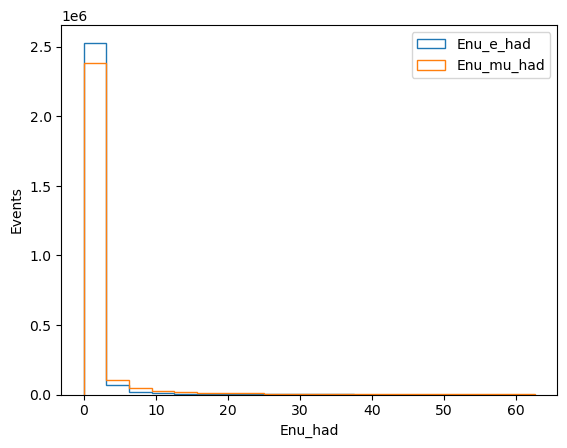

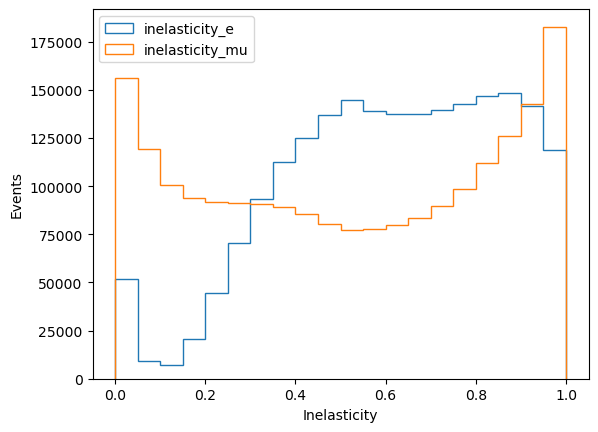

In [3]:
import matplotlib.pyplot as plt

_, bins, _ = plt.hist(data["Enu_e_had"], label="Enu_e_had", histtype="step", bins=20)
plt.hist(data["Enu_mu_had"], label="Enu_mu_had", histtype="step", bins=bins)
plt.legend()
plt.xlabel("Enu_had")
plt.ylabel("Events")
plt.show()

filtered = data.filter(pl.col("inelasticity_e") != 1.0).filter(
    pl.col("inelasticity_mu") != 1.0
)
_, bins, _ = plt.hist(
    filtered["inelasticity_e"], label="inelasticity_e", histtype="step", bins=20
)
plt.hist(
    filtered["inelasticity_mu"], label="inelasticity_mu", histtype="step", bins=bins
)
plt.legend()
plt.xlabel("Inelasticity")
plt.ylabel("Events")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# get your input data into an array which is N_events x N_variables
X_data = data.to_numpy()

# create an array of truth labels (one per event) - 0 for neutrino, 1 for anti-neutrino
y_data = (X_data[:, 4] < 0).astype(int)

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42
)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    n_estimators=100, learning_rate=1.0, max_depth=None, random_state=0
).fit(X_train, y_train)

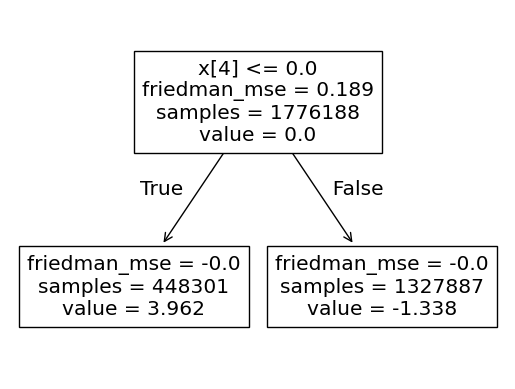

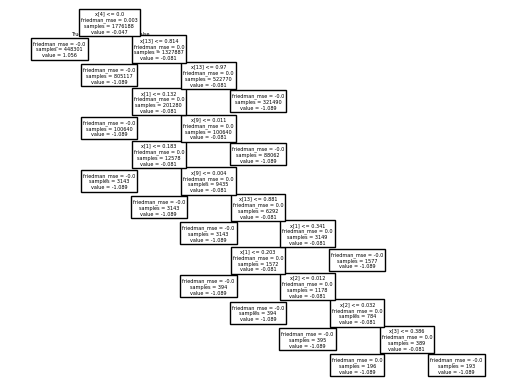

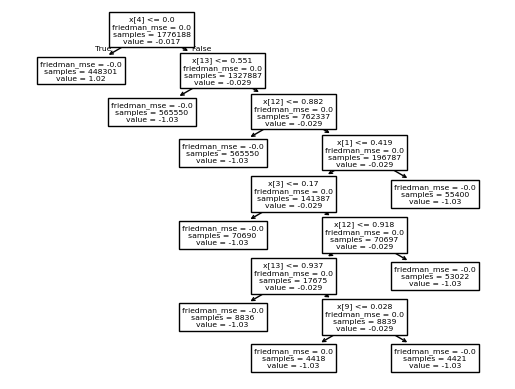

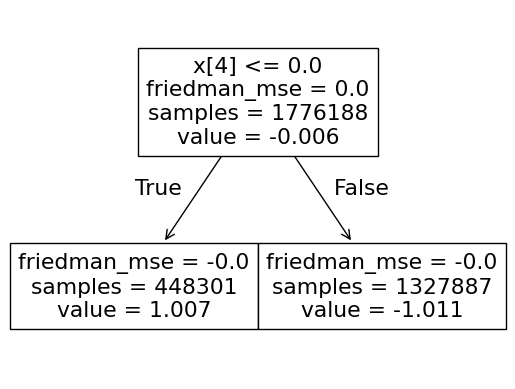

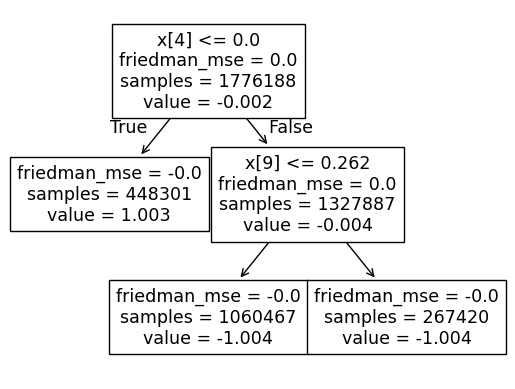

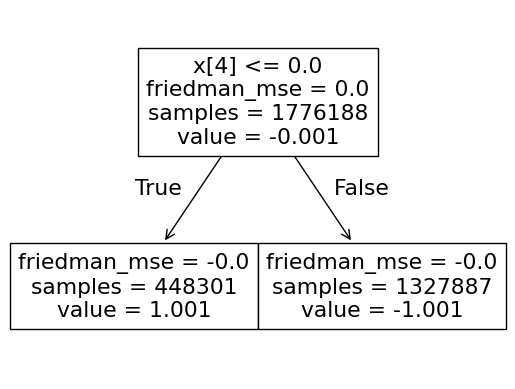

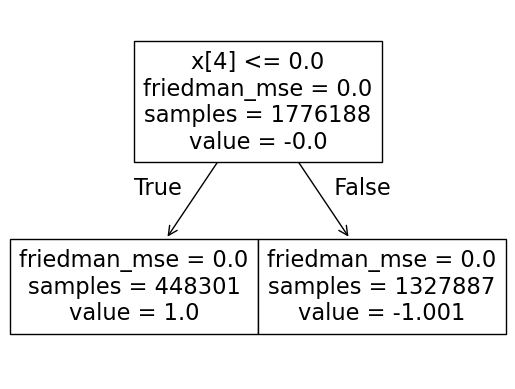

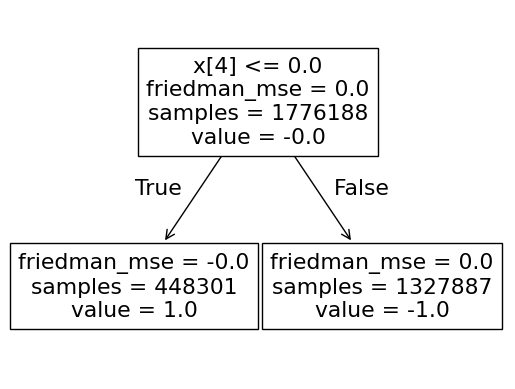

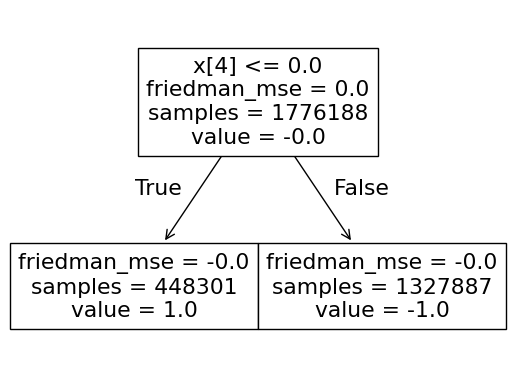

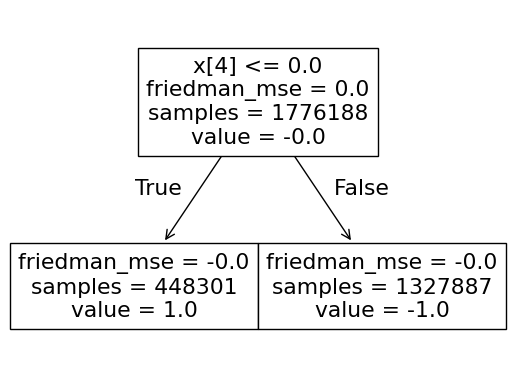

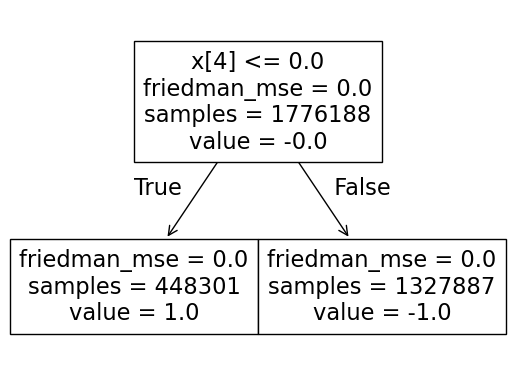

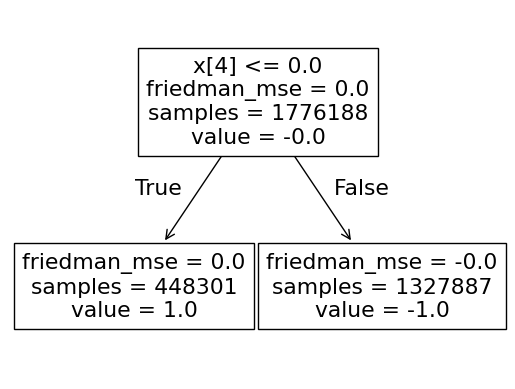

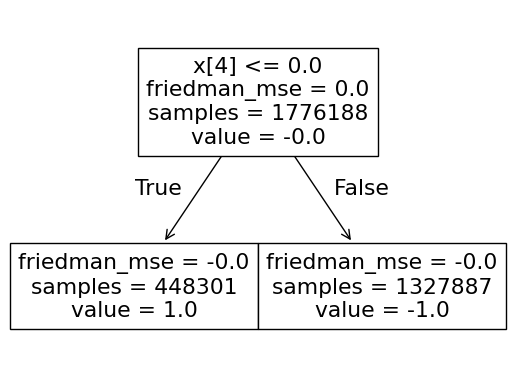

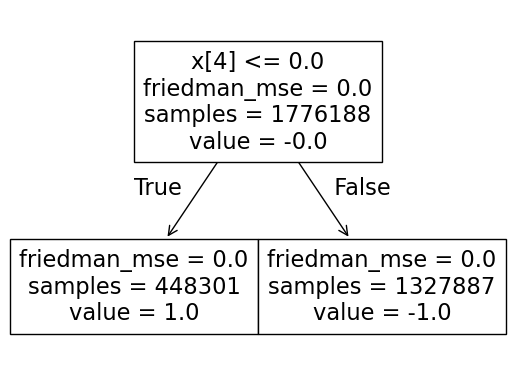

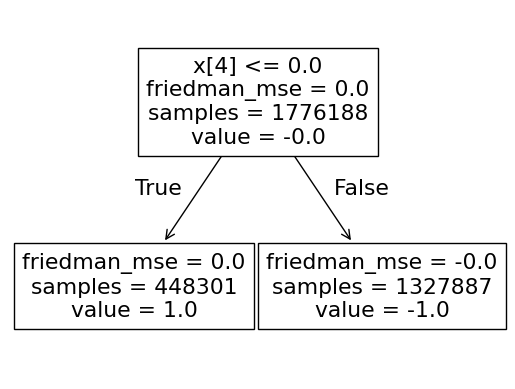

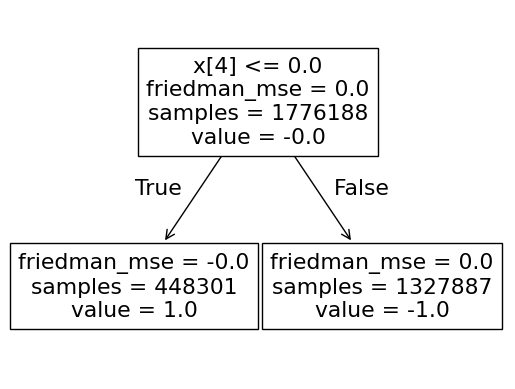

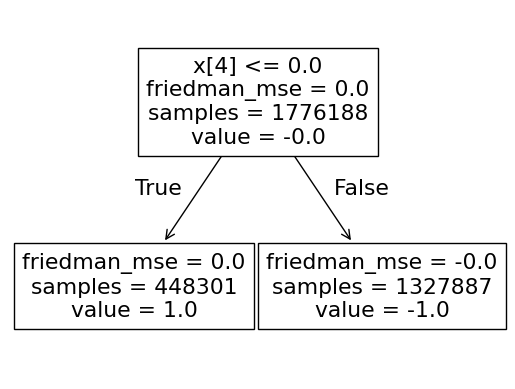

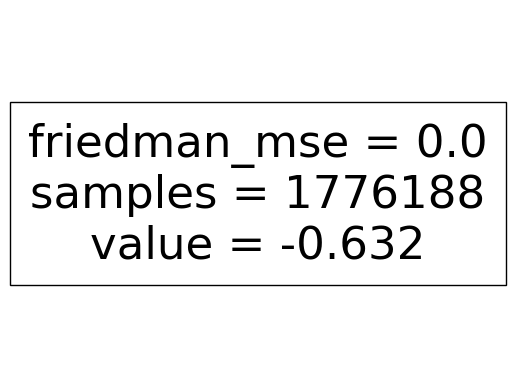

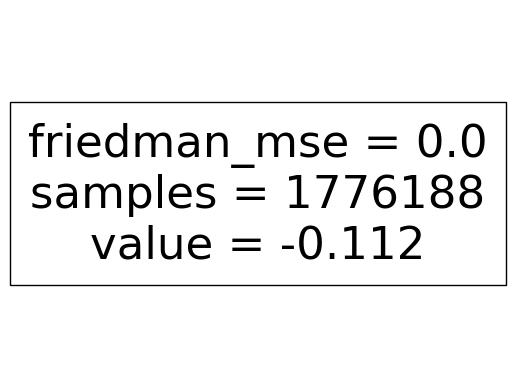

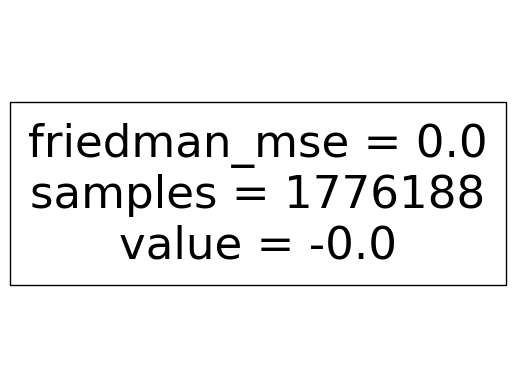

In [52]:
from sklearn.tree import plot_tree

for i in range(20):
    plt.figure()
    gbc_sub_tree = clf.estimators_[i, 0]
    plot_tree(gbc_sub_tree)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [ ]:
# this will be a value between 0 and 1 for each event, indicating "probability" that the event is anti-neutrino

# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)